In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('battery_anomalies.csv')

print(f"Total anomalies detected: {len(df)}")
df.head()

Total anomalies detected: 888


,vah_code,cycle_number,anomaly_type,details
0,VAH01,0,voltage_out_of_range,Voltage outside safe Li-ion range (2.5-4.3V)
1,VAH01,0,abnormal_capacity,Capacity significantly different from typical
2,VAH01,1,voltage_out_of_range,Voltage outside safe Li-ion range (2.5-4.3V)
3,VAH01,2,voltage_out_of_range,Voltage outside safe Li-ion range (2.5-4.3V)
4,VAH01,5,current_spikes,Abnormally high current detected


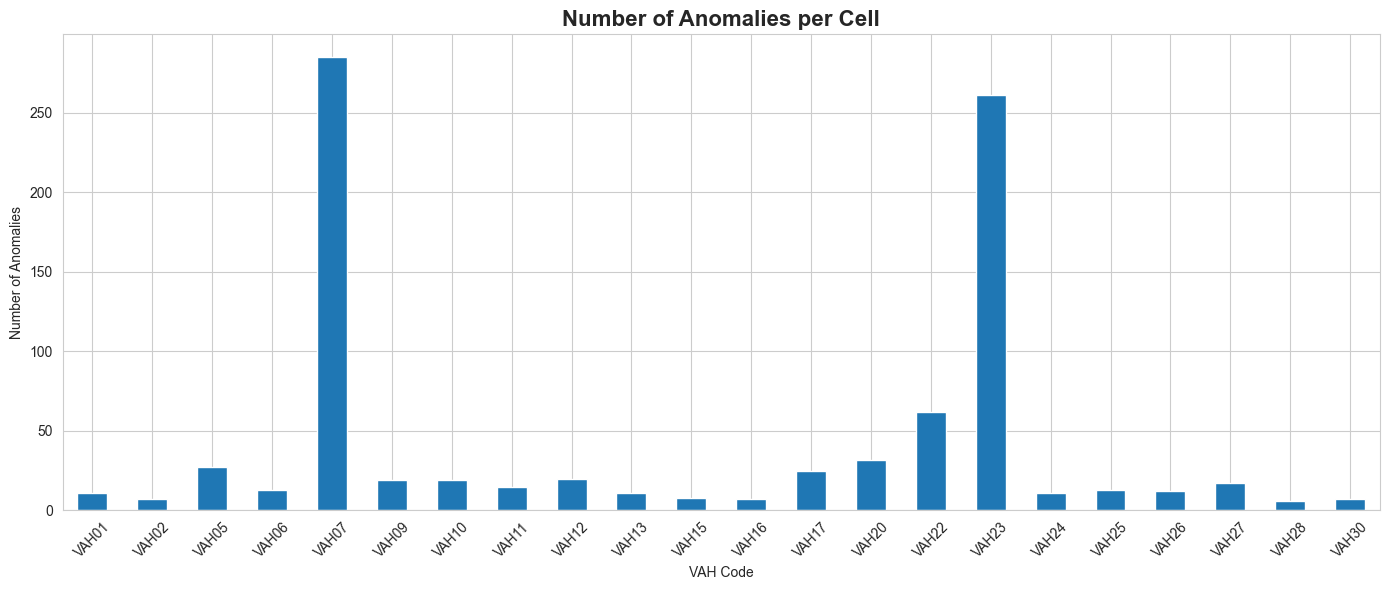

In [5]:
# Anomalies by cell (bar chart)
fig, ax = plt.subplots(figsize=(14, 6))
df['vah_code'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Number of Anomalies per Cell', fontsize=16, fontweight='bold')
ax.set_xlabel('VAH Code')
ax.set_ylabel('Number of Anomalies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



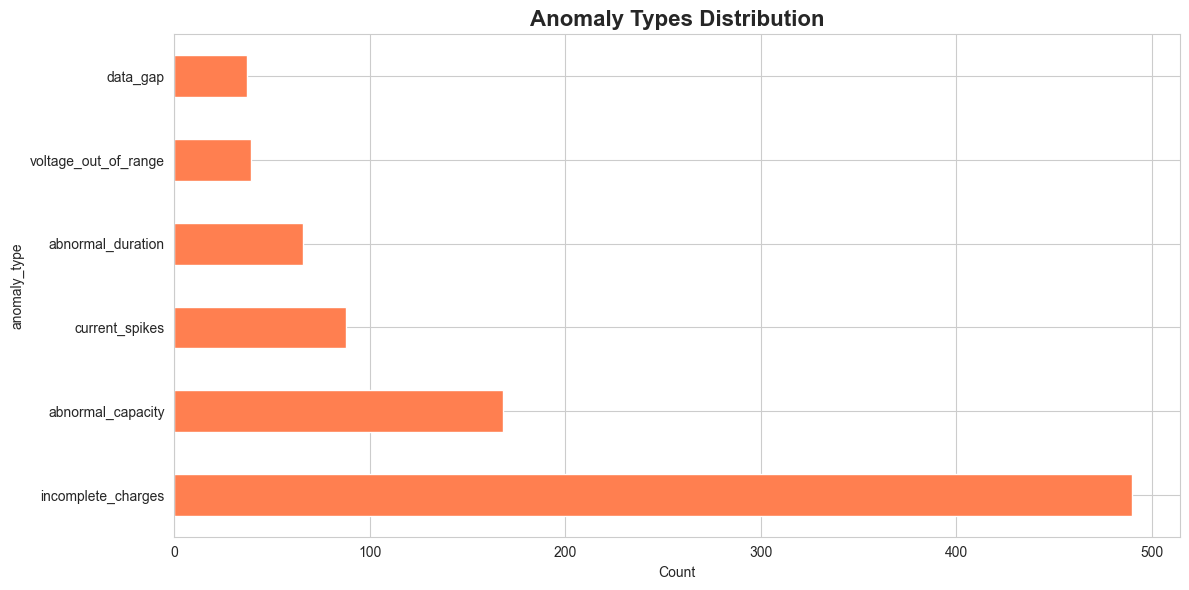

In [6]:
# Anomaly types distribution
fig, ax = plt.subplots(figsize=(12, 6))
df['anomaly_type'].value_counts().plot(kind='barh', ax=ax, color='coral')
ax.set_title('Anomaly Types Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

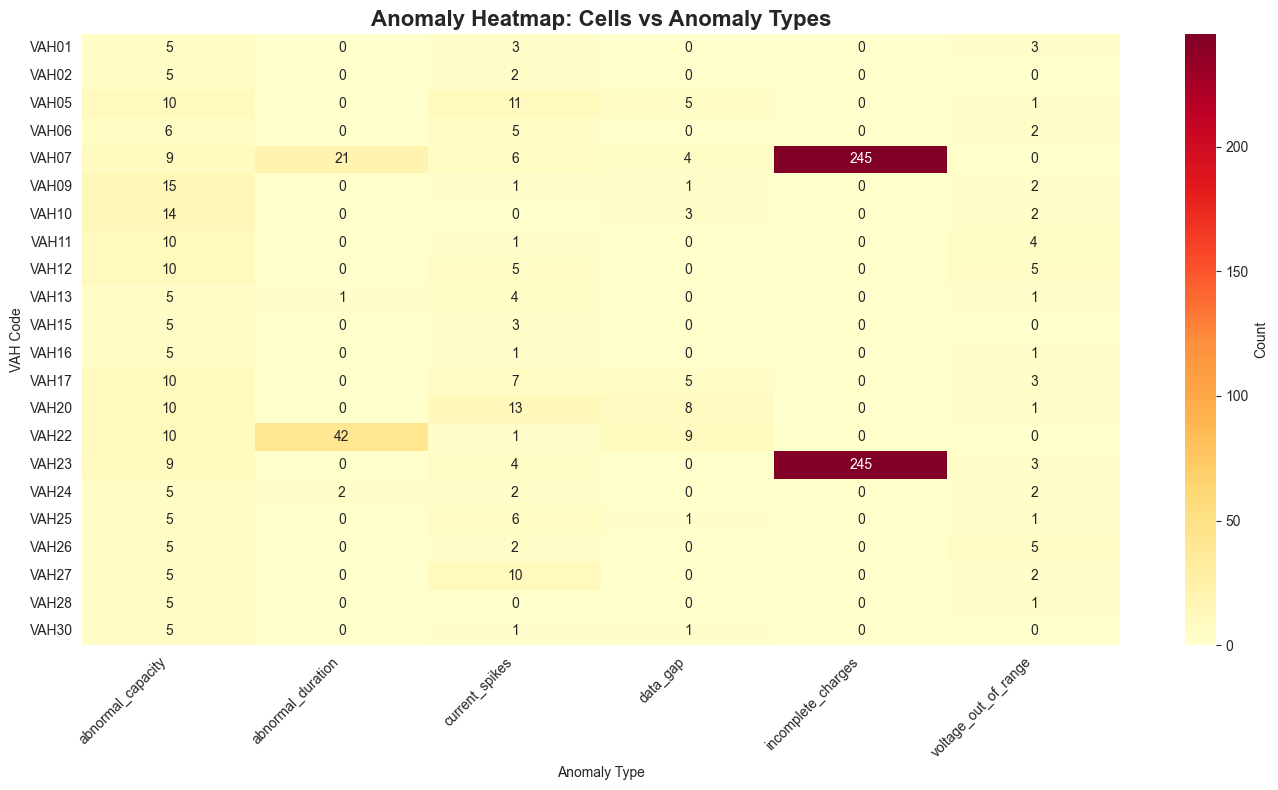

In [7]:
# Heatmap: Which cells have which anomalies?
pivot = df.pivot_table(
    index='vah_code', 
    columns='anomaly_type', 
    values='cycle_number', 
    aggfunc='count', 
    fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Anomaly Heatmap: Cells vs Anomaly Types', fontsize=16, fontweight='bold')
plt.xlabel('Anomaly Type')
plt.ylabel('VAH Code')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# 4. Timeline: When do anomalies occur in cycle lifecycle?
fig = px.scatter(
    df, 
    x='cycle_number', 
    y='vah_code',
    color='anomaly_type',
    title='Anomaly Timeline Across Cycle Numbers',
    labels={'cycle_number': 'Cycle Number', 'vah_code': 'Cell'},
    height=600,
    hover_data=['details']
)
fig.update_layout(xaxis_title='Cycle Number', yaxis_title='VAH Code')
fig.show()

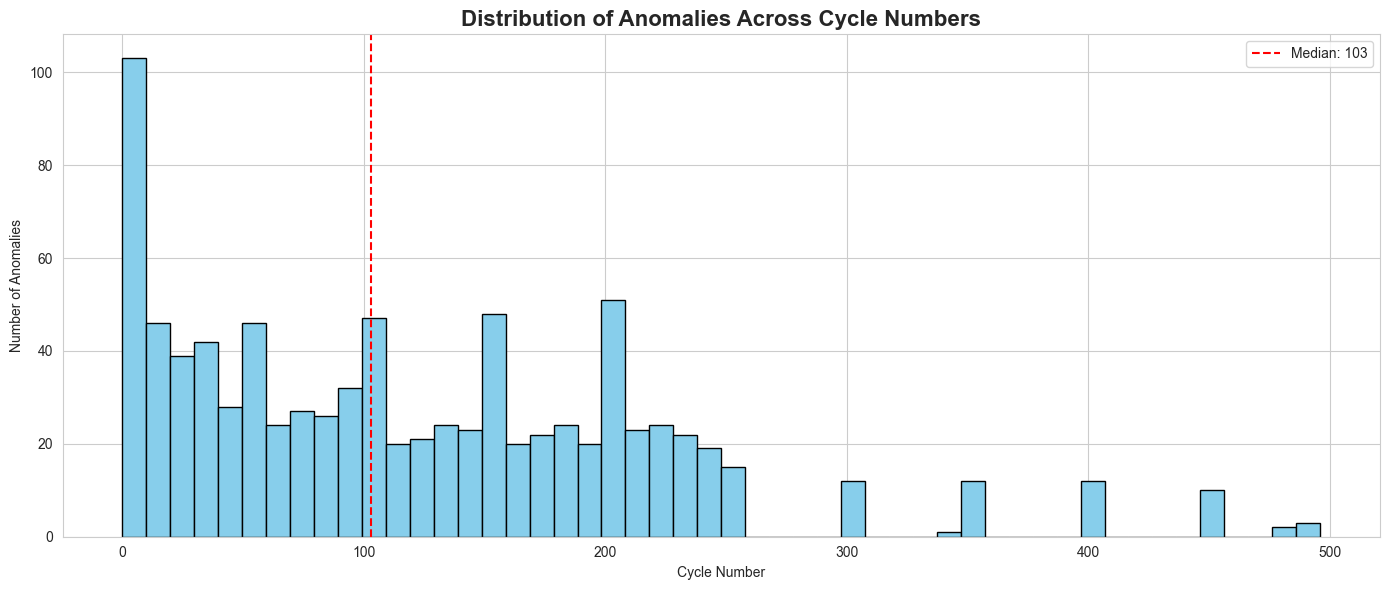

In [9]:
# Anomalies over cycle progression (histogram)
plt.figure(figsize=(14, 6))
plt.hist(df['cycle_number'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Anomalies Across Cycle Numbers', fontsize=16, fontweight='bold')
plt.xlabel('Cycle Number')
plt.ylabel('Number of Anomalies')
plt.axvline(df['cycle_number'].median(), color='red', linestyle='--', label=f'Median: {df["cycle_number"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

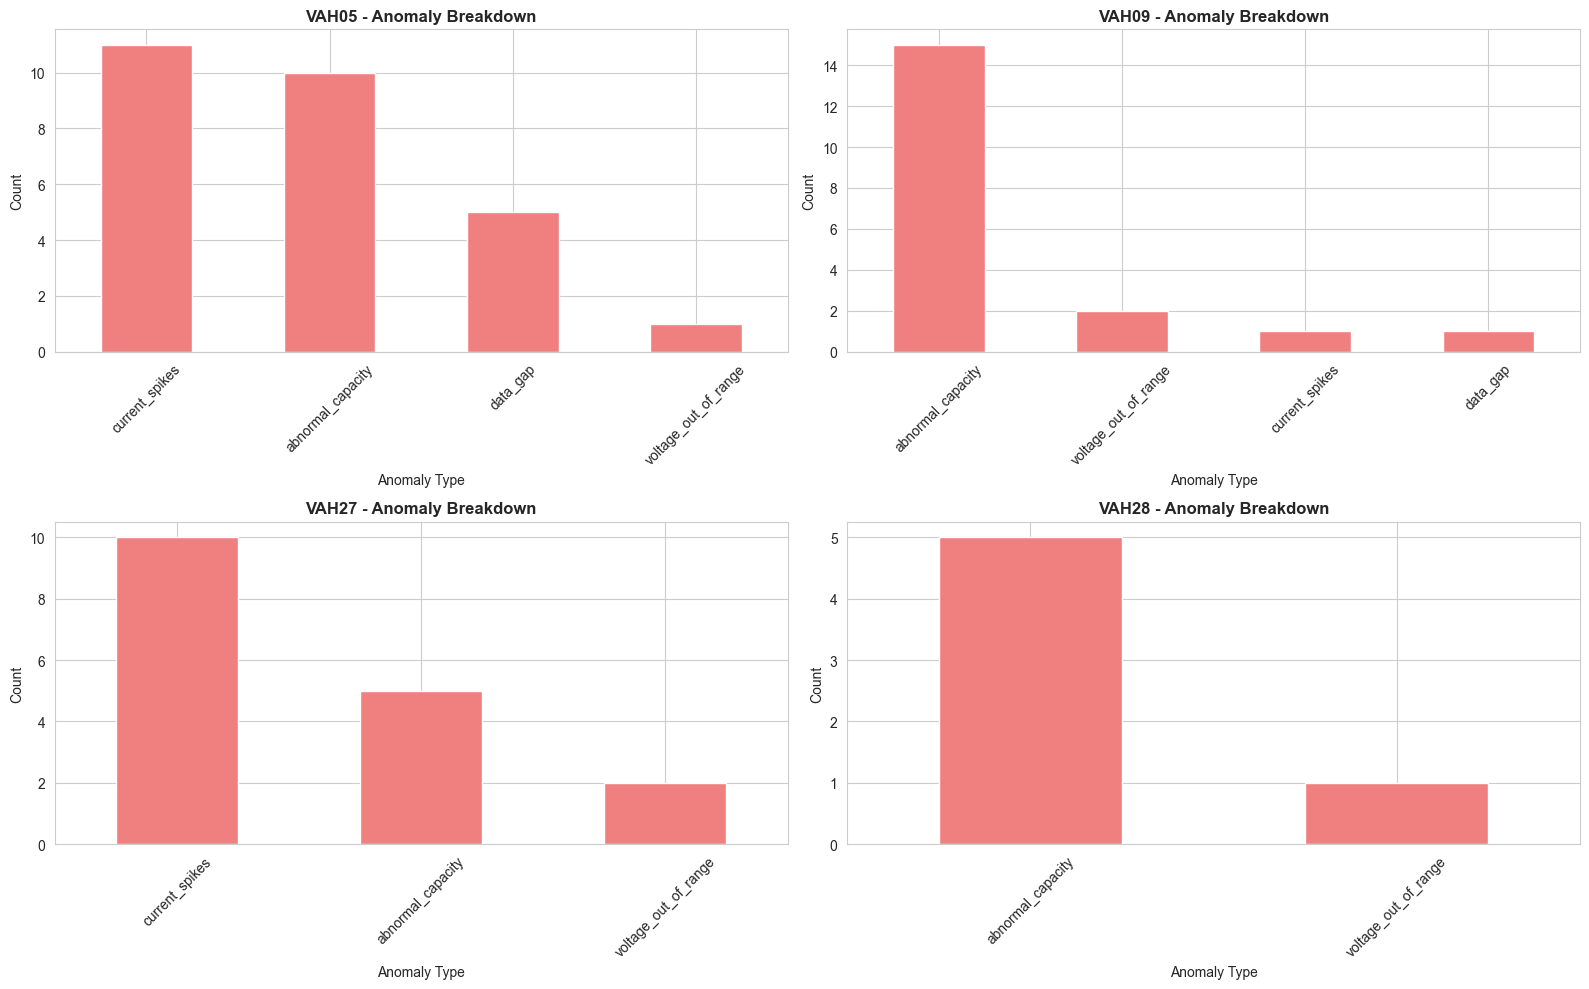

In [10]:
# Breakdown by specific cells with known issues
problem_cells = ['VAH05', 'VAH09', 'VAH27', 'VAH28']
df_problems = df[df['vah_code'].isin(problem_cells)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for idx, cell in enumerate(problem_cells):
    ax = axes[idx // 2, idx % 2]
    cell_data = df_problems[df_problems['vah_code'] == cell]
    cell_data['anomaly_type'].value_counts().plot(kind='bar', ax=ax, color='lightcoral')
    ax.set_title(f'{cell} - Anomaly Breakdown', fontweight='bold')
    ax.set_xlabel('Anomaly Type')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Summary statistics table
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
summary = df.groupby('vah_code').agg({
    'cycle_number': ['count', 'min', 'max'],
    'anomaly_type': lambda x: x.nunique()
}).round(2)
summary.columns = ['Total Anomalies', 'First Cycle', 'Last Cycle', 'Unique Types']
print(summary)


SUMMARY STATISTICS
          Total Anomalies  First Cycle  Last Cycle  Unique Types
vah_code                                                        
VAH01                  11            0         200             3
VAH02                   7            0         221             2
VAH05                  27            0         450             4
VAH06                  13            0         225             3
VAH07                 285            0         249             5
VAH09                  19            0         200             4
VAH10                  19            0         400             3
VAH11                  15            0         450             3
VAH12                  20            0         496             3
VAH13                  11            0         220             4
VAH15                   8            0         200             2
VAH16                   7            0         200             3
VAH17                  25            0         480             4
VAH20